# Celda 1 — Montar Drive e imports


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os, json
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

BASE_PATH = '/content/drive/MyDrive/project_factoria/waste_classifier'
UNIFIED   = os.path.join(BASE_PATH, 'datasets/unified')
METADATA  = os.path.join(BASE_PATH, 'datasets/metadata')
OUTPUTS   = os.path.join(BASE_PATH, 'outputs')

CLASSES = ['carton', 'papel', 'metal', 'plastico', 'vidrio', 'organico', 'no_reciclable']

# Verificar GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Dispositivo: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM disponible: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Mounted at /content/drive
Dispositivo: cpu


# Celda 2 — Definir las transformaciones


In [ ]:
# Medias y std de ImageNet — usamos estas porque vamos a hacer transfer learning
# El backbone ya fue entrenado con estas normalizaciones
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# TRAIN: resize + augmentation + normalización
transform_train = transforms.Compose([
    transforms.Resize((256, 256)),           # un poco más grande para poder recortar
    transforms.RandomCrop(224),              # crop aleatorio a 224 — añade variabilidad posicional
    transforms.RandomHorizontalFlip(p=0.5),  # volteo horizontal aleatorio
    transforms.RandomRotation(degrees=15),   # rotación ligera ±15°
    transforms.ColorJitter(                  # variaciones de color/brillo
        brightness=0.3,
        contrast=0.3,
        saturation=0.2,
        hue=0.05
    ),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

# VAL y TEST: solo resize fijo + normalización, sin augmentation
# Lo que el modelo ve en evaluación debe ser determinista
transform_val = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

print("Transforms definidos:")
print("\nTRAIN:", transform_train)
print("\nVAL/TEST:", transform_val)

Transforms definidos:

TRAIN: Compose(
    Resize(size=(256, 256), interpolation=bilinear, max_size=None, antialias=True)
    RandomCrop(size=(224, 224), padding=None)
    RandomHorizontalFlip(p=0.5)
    RandomRotation(degrees=[-15.0, 15.0], interpolation=nearest, expand=False, fill=0)
    ColorJitter(brightness=(0.7, 1.3), contrast=(0.7, 1.3), saturation=(0.8, 1.2), hue=(-0.05, 0.05))
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)

VAL/TEST: Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


# Celda 3 — Crear los datasets de PyTorch


In [ ]:
# ImageFolder lee automáticamente subcarpetas como clases
# Espera estructura: split/clase/imagen.jpg  — que es exactamente lo que tenemos
dataset_train = datasets.ImageFolder(
    root=os.path.join(UNIFIED, 'train'),
    transform=transform_train
)
dataset_val = datasets.ImageFolder(
    root=os.path.join(UNIFIED, 'val'),
    transform=transform_val
)
dataset_test = datasets.ImageFolder(
    root=os.path.join(UNIFIED, 'test'),
    transform=transform_val
)

# Verificar que el orden de clases coincide con el nuestro
print("Clases detectadas por ImageFolder:")
for i, c in enumerate(dataset_train.classes):
    print(f"  idx {i} → {c}")

print(f"\nTamaños:")
print(f"  Train: {len(dataset_train)}")
print(f"  Val:   {len(dataset_val)}")
print(f"  Test:  {len(dataset_test)}")

Clases detectadas por ImageFolder:
  idx 0 → carton
  idx 1 → metal
  idx 2 → no_reciclable
  idx 3 → organico
  idx 4 → papel
  idx 5 → plastico
  idx 6 → vidrio

Tamaños:
  Train: 18242
  Val:   2276
  Test:  2276


# Celda 4 — Cargar class weights y crear DataLoaders


In [ ]:
# Cargar los weights calculados en el Notebook 01
with open(os.path.join(METADATA, 'class_weights.json')) as f:
    weights_dict = json.load(f)

# Convertir a tensor en el mismo orden que ImageFolder detectó las clases
class_weights = torch.tensor(
    [weights_dict[c] for c in dataset_train.classes],
    dtype=torch.float
).to(device)

print("Class weights tensor:")
for c, w in zip(dataset_train.classes, class_weights):
    print(f"  {c:<18} {w:.4f}")

# DataLoaders — num_workers=2 es seguro en Colab
BATCH_SIZE = 32

loader_train = DataLoader(
    dataset_train,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True   # acelera la transferencia CPU→GPU
)
loader_val = DataLoader(
    dataset_val,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)
loader_test = DataLoader(
    dataset_test,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print(f"\nDataLoaders creados — batch size: {BATCH_SIZE}")
print(f"  Batches en train: {len(loader_train)}")
print(f"  Batches en val:   {len(loader_val)}")
print(f"  Batches en test:  {len(loader_test)}")

Class weights tensor:
  carton             1.8548
  metal              1.6525
  no_reciclable      0.3292
  organico           1.7776
  papel              1.5186
  plastico           1.4350
  vidrio             1.1108

DataLoaders creados — batch size: 32
  Batches en train: 571
  Batches en val:   72
  Batches en test:  72


# Celda 5 — Verificar un batch real


In [ ]:
# Sacamos un batch del loader de train y verificamos shapes y rangos
imagenes, etiquetas = next(iter(loader_train))

print(f"Shape del batch de imágenes: {imagenes.shape}")
print(f"  → [batch_size, canales, alto, ancho] = [{imagenes.shape[0]}, {imagenes.shape[1]}, {imagenes.shape[2]}, {imagenes.shape[3]}]")
print(f"\nShape de etiquetas: {etiquetas.shape}")
print(f"Etiquetas en este batch: {etiquetas.tolist()}")

print(f"\nRango de valores después de normalización:")
print(f"  min: {imagenes.min():.3f}  max: {imagenes.max():.3f}")
print(f"  (esperado: aprox -2.1 a 2.6 con normalización ImageNet)")

print(f"\nDistribución de clases en este batch:")
for idx, nombre in enumerate(dataset_train.classes):
    count = (etiquetas == idx).sum().item()
    if count > 0:
        print(f"  {nombre:<18} {count}")

Shape del batch de imágenes: torch.Size([32, 3, 224, 224])
  → [batch_size, canales, alto, ancho] = [32, 3, 224, 224]

Shape de etiquetas: torch.Size([32])
Etiquetas en este batch: [5, 2, 2, 2, 2, 6, 6, 1, 6, 2, 6, 2, 2, 0, 2, 2, 0, 4, 5, 6, 1, 4, 2, 6, 4, 2, 6, 0, 2, 2, 3, 4]

Rango de valores después de normalización:
  min: -2.118  max: 2.640
  (esperado: aprox -2.1 a 2.6 con normalización ImageNet)

Distribución de clases en este batch:
  carton             3
  metal              2
  no_reciclable      13
  organico           1
  papel              4
  plastico           2
  vidrio             7


# Celda 6 — Visualizar el batch con las augmentaciones aplicadas


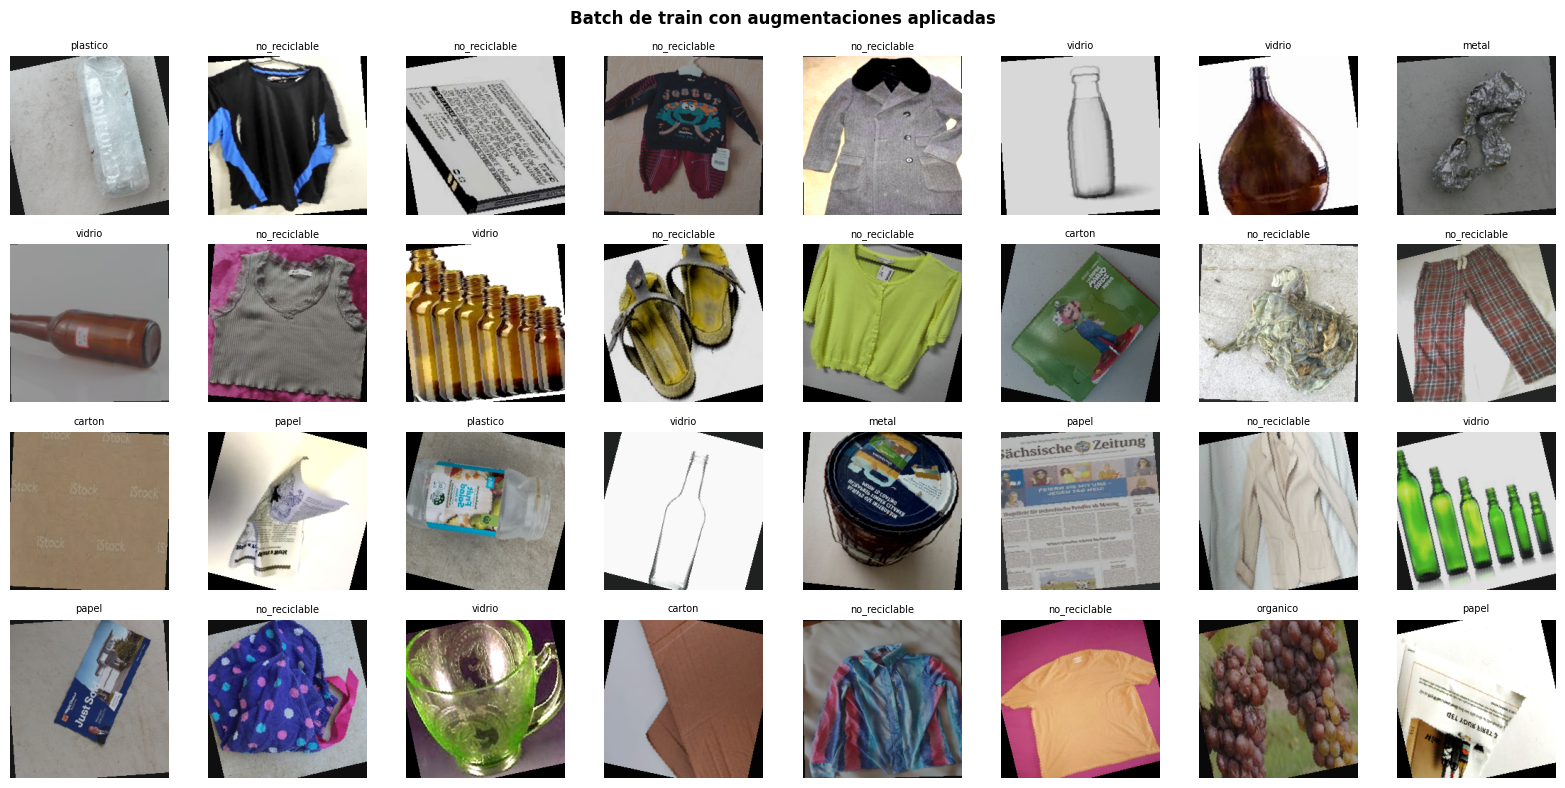

Guardado: sample_batch_augmented.png


In [ ]:
def denormalizar(tensor):
    """Invierte la normalización ImageNet para poder visualizar."""
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std  = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    return torch.clamp(tensor * std + mean, 0, 1)

fig, axes = plt.subplots(4, 8, figsize=(16, 8))
fig.suptitle('Batch de train con augmentaciones aplicadas', fontweight='bold')

for i, ax in enumerate(axes.flat):
    if i >= len(imagenes):
        ax.axis('off')
        continue
    img = denormalizar(imagenes[i]).permute(1, 2, 0).numpy()
    ax.imshow(img)
    ax.set_title(dataset_train.classes[etiquetas[i]], fontsize=7)
    ax.axis('off')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS, 'sample_batch_augmented.png'), dpi=120, bbox_inches='tight')
plt.show()
print("Guardado: sample_batch_augmented.png")

# Celda 7 — Guardar configuración para el notebook de entrenamiento


In [ ]:
# Guardamos todo lo necesario para no repetirlo en el Notebook 04
config = {
    'batch_size':    BATCH_SIZE,
    'num_classes':   len(CLASSES),
    'classes':       dataset_train.classes,
    'imagenet_mean': IMAGENET_MEAN,
    'imagenet_std':  IMAGENET_STD,
    'img_size':      224,
    'unified_path':  UNIFIED,
    'device':        str(device)
}

config_path = os.path.join(METADATA, 'config.json')
with open(config_path, 'w') as f:
    json.dump(config, f, indent=2)

print("✓ config.json guardado")
print("\nResumen de configuración:")
for k, v in config.items():
    print(f"  {k:<18} {v}")
print("\nNotebook 03 completo. Siguiente: 04_train")

✓ config.json guardado

Resumen de configuración:
  batch_size         32
  num_classes        7
  classes            ['carton', 'metal', 'no_reciclable', 'organico', 'papel', 'plastico', 'vidrio']
  imagenet_mean      [0.485, 0.456, 0.406]
  imagenet_std       [0.229, 0.224, 0.225]
  img_size           224
  unified_path       /content/drive/MyDrive/project_factoria/waste_classifier/datasets/unified
  device             cpu

Notebook 03 completo. Siguiente: 04_train
